In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import streamlit as st

DATA PROCESSING

In [2]:
Patients = pd.read_csv("Patients.csv")
Diagnosis = pd.read_csv("Diagnosis.csv")
Outcomes = pd.read_csv("Outcomes.csv")
Labs = pd.read_csv("Labs.csv")

In [3]:
Patients = Patients.merge(Diagnosis, on ="DiagnosisID")
Patients = Patients.merge(Outcomes, on ="OutcomeID")

In [4]:
Patients["AdmissionDate"] = pd.to_datetime(Patients["AdmissionDate"], format='%d/%m/%y')
Patients["DischargeDate"] = pd.to_datetime(Patients["DischargeDate"], format='%d/%m/%y')
Patients["Length_of_Stay"] = (Patients["DischargeDate"] - Patients["AdmissionDate"]).dt.days

In [5]:
Patients["OutcomeEncoded"] = Patients["OutcomeName"].map({"Recovered":0, "Complicated":1, "Deceased":1})

In [6]:
Patients["HighRisk"] = np.where(( Patients["Age"] > 65 ) | (Patients["OutcomeName"].isin(["Complicated", "Deceased"])), 1, 0)

In [7]:
abnormal_conditions = {
    "Blood Sugar": lambda x: x > 120,
    "Cholesterol": lambda x: x > 200,
    "Hemoglobin": lambda x: x < 13
}

def count_abnormal_labs(patient_id):
    patient_labs = Labs[Labs["PatientID"] == patient_id]
    count = 0
    
    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs["TestName"] == test_name]
        
        test_results = test_results.dropna(subset=["Result"])
        count += test_results["Result"].apply(condition).sum()
        
    return count

Patients["AbnormalLabCount"] = Patients["PatientID"].apply(count_abnormal_labs)

MODEL TRAINING

In [8]:
features = Patients[["Age", "Length_of_Stay", "TreatmentCost"]]
target = Patients["OutcomeEncoded"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.3, 
    random_state=42
)

ML-

1. Supervised - Input + Output - Linear Regression, Logistic Regression etc.
2. Unsupervised - Input
3. Reinforcement - Rewards

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.36      0.50      0.42        60
weighted avg       0.51      0.72      0.60        60



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


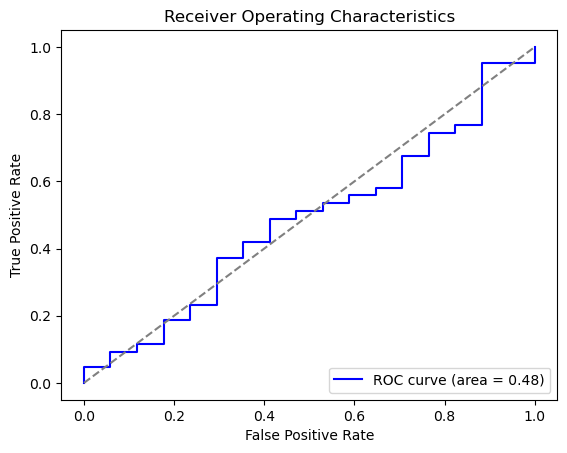

In [12]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristics')
plt.legend(loc="lower right")

plt.show()

In [13]:
import joblib

In [14]:
joblib.dump(model,"Risk_Model1.ipynb")

['Risk_Model1.ipynb']

In [15]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [16]:
model = joblib.load("Risk_Model1.ipynb")

In [19]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model (correct file)
model = joblib.load("risk_model.pkl")

st.title("Healthcare Risk Stratification App")

# Inputs
age = st.number_input("Age", min_value=0, step=1)
length_of_stay = st.number_input("Length of Stay (days)", min_value=0, step=1)
treatment_cost = st.number_input("Treatment Cost", min_value=0.0, format="%.2f")

# Prediction
if st.button("Predict"):
    input_data = pd.DataFrame(
        [[age, length_of_stay, treatment_cost]],
        columns=['Age', 'Length_of_Stay', 'TreatmentCost']
    )

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.success(f"Risk Prediction: {'High Risk' if prediction == 1 else 'Low Risk'}")
    st.info(f"Risk Probability: {round(probability, 2)}")

2026-03-30 11:35:23.350 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.385 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-30 11:35:23.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:35:23.387 Thread 'MainThread': m

In [18]:
import joblib
joblib.dump(model, "risk_model.pkl")

['risk_model.pkl']